In [ ]:
import numpy as np
from matplotlib import pyplot as plt

from letalker.constants import vocaltract_areas
from letalker.constants import vocaltract_resolution as length
from letalker.vt_components import segments, cascade, endpoints, junctions

area = 4.0
fs = 44100
sample_kws = {"method": "bilinear"}


series = segments.SeriesNetwork(
    segments.DefaultInertance(),
    segments.DefaultViscousLossTF(resistive_only=True),
    # segments.DefaultLaminarResistance(),
)
shunt = segments.ShuntNetwork(
    segments.DefaultCompliance(),
    # segments.DefaultYieldingWall(),
    # segments.DefaultHeatLossGain(),
)

segm = segments.TSegment(series, shunt)
# segm = segments.SeriesNetwork(segments.DefaultInertance(),)

jct = junctions.LosslessJunction()

vf_src = endpoints.VFFlowSource()
sys = vf_src(area)
for i in range(22):
    sys = cascade.combine(sys, segm(area, 2 * length))
    if i < 21:
        sys = cascade.combine(sys, jct(area, area))

rad = endpoints.TwoPortAcousticRadiator()
sys = cascade.combine(sys, rad(area))

print(sys.D)
# sys = cascade.combine(series(areas[0], length),shunt(areas[0],2*length))

# sys = segm(area,2*length)
# dsys = sys.sample(1 / fs, **sample_kws)
# print(dsys)


[[0.]]


C:\Users\tikuma\AppData\Local\Temp\ipykernel_14484\3535501664.py:23: RuntimeWarning: divide by zero encountered in log10
  ax[0].plot(f, 20 * np.log10(np.abs(H)))
C:\Users\tikuma\AppData\Local\Temp\ipykernel_14484\3535501664.py:26: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(f[:-1], -np.angle(H[1:] / H[:-1]) / domega * fs)


(0.0, 100.0)

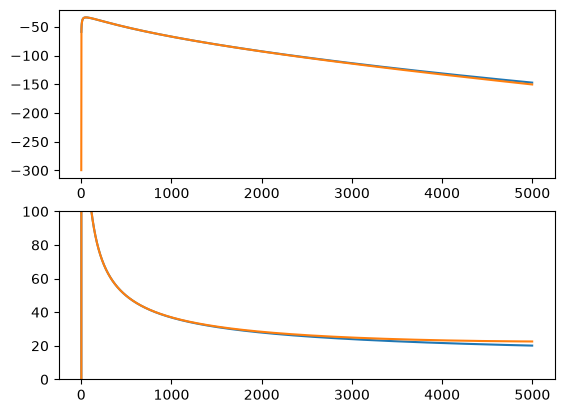

In [140]:
from letalker.vt_components.sample import sample

Ts = 1 / fs

# f = np.arange(10, 5000, 1)
f = np.arange(5000)
omega = 2 * np.pi * f
prewarp_frequency = 2 * np.pi * 1000

dsys = sample(sys, Ts, "bilinear", prewarp_frequency=prewarp_frequency)

# _, H = freqs(tf.num[0][0], tf.den[0][0], omega)

H = sys.frequency_response(omega)[0, 0].complex
Hz = dsys.frequency_response(omega)[0, 0].complex

# _, Hz = freqz(dnum[0], dden[0], f, fs=fs)
domega = np.diff(omega)

# _,tau = group_delay(dlti, f, fs=fs)

fig, ax = plt.subplots(2, 1)
ax[0].plot(f, 20 * np.log10(np.abs(H)))
ax[0].plot(f, 20 * np.log10(np.abs(Hz)))
# ax[0].set_ylim(-50,10)
ax[1].plot(f[:-1], -np.angle(H[1:] / H[:-1]) / domega * fs)
ax[1].plot(f[:-1], -np.angle(Hz[1:] / Hz[:-1]) / domega * fs)
ax[1].set_ylim(0, 100)
